# Standard QFT

# Project 7: Quantum Fourier Transform (QFT)

**Objective:** Build a scalable, $n$-qubit Quantum Fourier Transform function that translates computational basis states into phase rotations.

**Theory:**
The classical discrete Fourier transform maps data from the time domain to the frequency domain. The Quantum Fourier Transform (QFT) does the same thing for quantum amplitudes. It transforms a state from the computational basis ($|0\rangle$ and $|1\rangle$) into the Fourier basis. 

In the Fourier basis, the information is encoded in the relative phases (the angles) between the computational states. 
- The most significant bit makes a half-turn rotation.
- The next bit makes a quarter-turn rotation.
- The next makes an eighth-turn, and so on.

Because we need this exact circuit to build Quantum Phase Estimation (Project 8), we are going to package this logic into a clean, reusable Python function.

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from IPython.display import display
import numpy as np

print("Environment Ready.")

Environment Ready.


## Step 1: The Scalable QFT Function

To build the QFT for $n$ qubits, we iteratively apply two types of gates:
1.  **Hadamard ($H$) Gate:** Puts the target qubit into superposition on the equator of the Bloch sphere.
2.  **Controlled-Phase ($CP$) Gates:** Adds a specific phase rotation (e.g., $\pi/2$, $\pi/4$, $\pi/8$) depending on the state of the lesser significant qubits.

Finally, because the QFT logic naturally reverses the order of the qubits, we apply `SWAP` gates at the very end to match Qiskit's little-endian ordering.

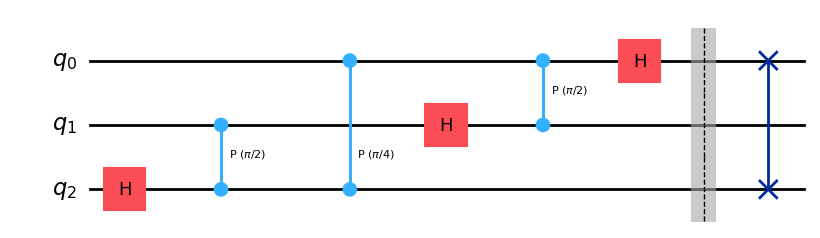

In [2]:
def build_qft(n: int) -> QuantumCircuit:
    """Constructs the Quantum Fourier Transform circuit for n qubits."""
    qc = QuantumCircuit(n, name="QFT")
    
    # Iterate through the qubits from highest to lowest
    for i in range(n - 1, -1, -1):
        # Apply the Hadamard gate
        qc.h(i)
        
        # Apply the controlled-phase rotations from the lesser qubits
        for j in range(i - 1, -1, -1):
            rotation_angle = np.pi / (2 ** (i - j))
            qc.cp(rotation_angle, j, i)
    
    qc.barrier()
    
    # Swap the qubits to match standard Qiskit ordering
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
        
    return qc

# Visualize a 3-qubit QFT
n_qubits = 3
qft_circuit = build_qft(n_qubits)
display(qft_circuit.draw('mpl'))

## Step 2: Visualizing the Phase Basis

If we run a QFT and measure the qubits, we will just get a random uniform distribution (like rolling dice), because the QFT puts everything into superposition. 

To prove the QFT actually worked, we must look at the **Statevector** using Bloch Spheres. We will input the computational number `5` (binary `101`), apply the QFT, and watch how the algorithm perfectly encodes the number `5` as distinct angle rotations along the equators of the spheres.

Circuit encoding the number 5 into the QFT:


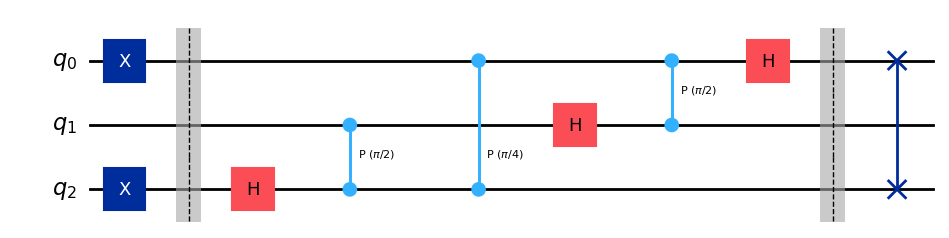


Notice the distinct Phase Rotations on the equator!


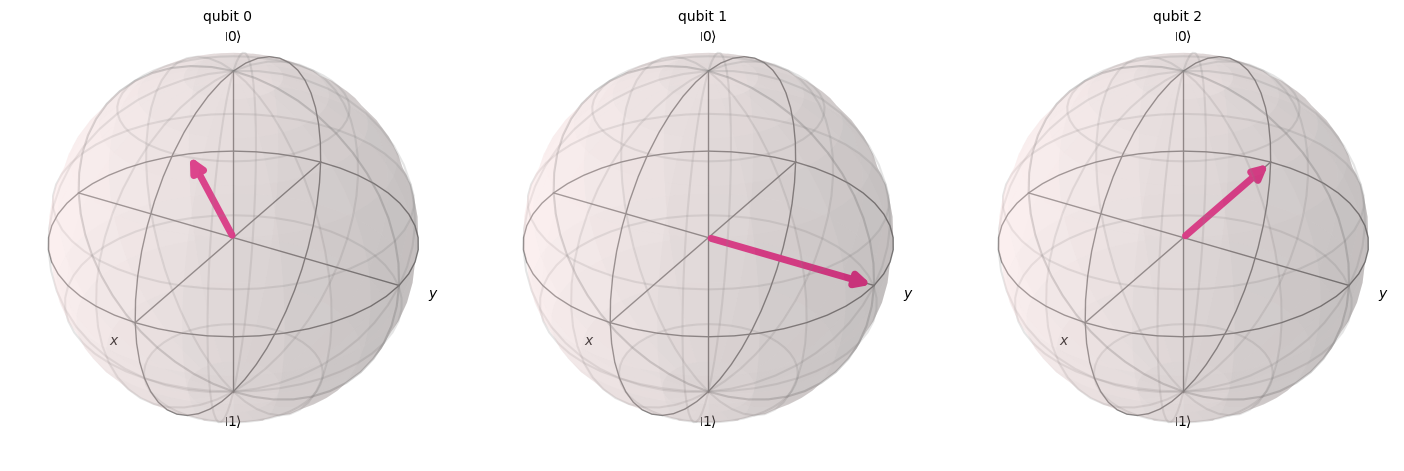

In [3]:
# Create a fresh circuit
test_qc = QuantumCircuit(3)

# 1. Encode the number 5 (Binary: 101)
# Qiskit is little-endian (qubit 0 is the far right bit)
test_qc.x(0) # Qubit 0 = 1
# Qubit 1 remains 0
test_qc.x(2) # Qubit 2 = 1

test_qc.barrier()

# 2. Apply our custom QFT
test_qc.compose(build_qft(3), inplace=True)

print("Circuit encoding the number 5 into the QFT:")
display(test_qc.draw('mpl'))

# 3. Extract the exact mathematical Statevector
state = Statevector(test_qc)

# 4. Plot the Bloch Spheres
print("\nNotice the distinct Phase Rotations on the equator!")
display(plot_bloch_multivector(state))